# CROCUS WXT archive — quick look

Loads the resampled WXT archive for one site and makes sanity-check plots.
Plots use the `mean` statistic. There is no gas/PM QA/QC inventory here (that's
AQT-specific); instead, low-`count` bins — those built from too few raw samples
to be trustworthy — are masked out for display. The raw values stay in the
archive untouched; masking is applied only for the plots.

Two WXT-specific points worth knowing before reading the wind and rain panels:

- **Wind is vector-averaged.** The stored `wind_speed` mean is a *scalar*
  average (always ≥ the true vector speed), and the stored `wind_dir` mean is
  `NaN` because averaging compass degrees is meaningless. The physically correct
  wind comes from the `wind_u` / `wind_v` components: vector speed is
  `√(ū² + v̄²)` and direction is recovered from `atan2(-u,-v)`. This notebook plots the
  vector wind, not the stored scalars.
- **Rain is per-bin accumulation.** The WXT reports rain as a running counter;
  the archive's `rain` mean slot already holds the 5-min *increment* (mm in that
  bin), so it sums directly to a rainfall total. `std` is undefined (`NaN`).

- **Meteorology conventions.** In meteorology, u, v, and w are the three components of the wind vector in a Cartesian coordinate system:

  - Positive **u** is a wind from the **west**
  - Positive **v** is a wind from the **south**
  - Positive **w** is upward motion.

The last cells show data availability (`count`) and the high-frequency &rarr;
native-5-min transition that `count` reveals for historic nodes.

In [3]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import crocus_store as cs
from crocus_sites import NEIU

importlib.reload(cs)

<module 'crocus_store' from '/home/anderson/py/crocus/crocus_store.py'>

In [ ]:
SITE = NEIU          # change to plot a different site
ds = cs.load(SITE, 'wxt', outdir='archive')

print('vars:', list(ds.data_vars))
print('span:', str(ds.time.values[0])[:10], '->', str(ds.time.values[-1])[:10])
print('bins:', ds.sizes['time'])

vars: ['humidity', 'pressure', 'temp', 'rain', 'wind_speed', 'wind_u', 'wind_v', 'wind_dir']
span: 2023-05-05 -> 2025-12-15
bins: 250647


: 

## Count-based mask

`count` is the number of raw samples behind each 5-min bin. Historic WXT bins
are dense (~3000 samples), so a bin with very few samples is either the start of
an outage, a partial bin at a seam, or the post-transition native-5-min era
where each bin is a single reading. The mask below hides only the genuinely
sparse bins (`count` below a threshold) so they don't draw misleading line
segments across gaps. Nothing is removed from the archive.

In [4]:
# A bin needs at least this many raw samples to be plotted. Historic high-freq
# bins have thousands; this drops near-empty seam/outage bins without touching
# the dense data. Lower it (e.g. to 1) if you want to include native-5-min era.
MIN_COUNT = 100

count = ds['temp'].sel(statistic='count').to_series()
good = (count >= MIN_COUNT)

def clean_series(var):
    """mean series with low-count bins masked to NaN (display only),
    plus the raw series and stored units. Returns (raw, cleaned, units)."""
    da = ds[var].sel(statistic='mean')
    raw = da.to_series()
    cleaned = raw.where(good.values)
    return raw, cleaned, da.attrs.get('units', '')

print(f'bins total      : {len(count)}')
print(f'bins >= {MIN_COUNT:>4} cnt : {int(good.sum())}')
print(f'masked (sparse) : {int((~good).sum())}')

bins total      : 250647
bins >=  100 cnt : 241453
masked (sparse) : 9194


## Meteorology

Temperature, humidity, and pressure — the core thermodynamic state. Low-count
bins masked.

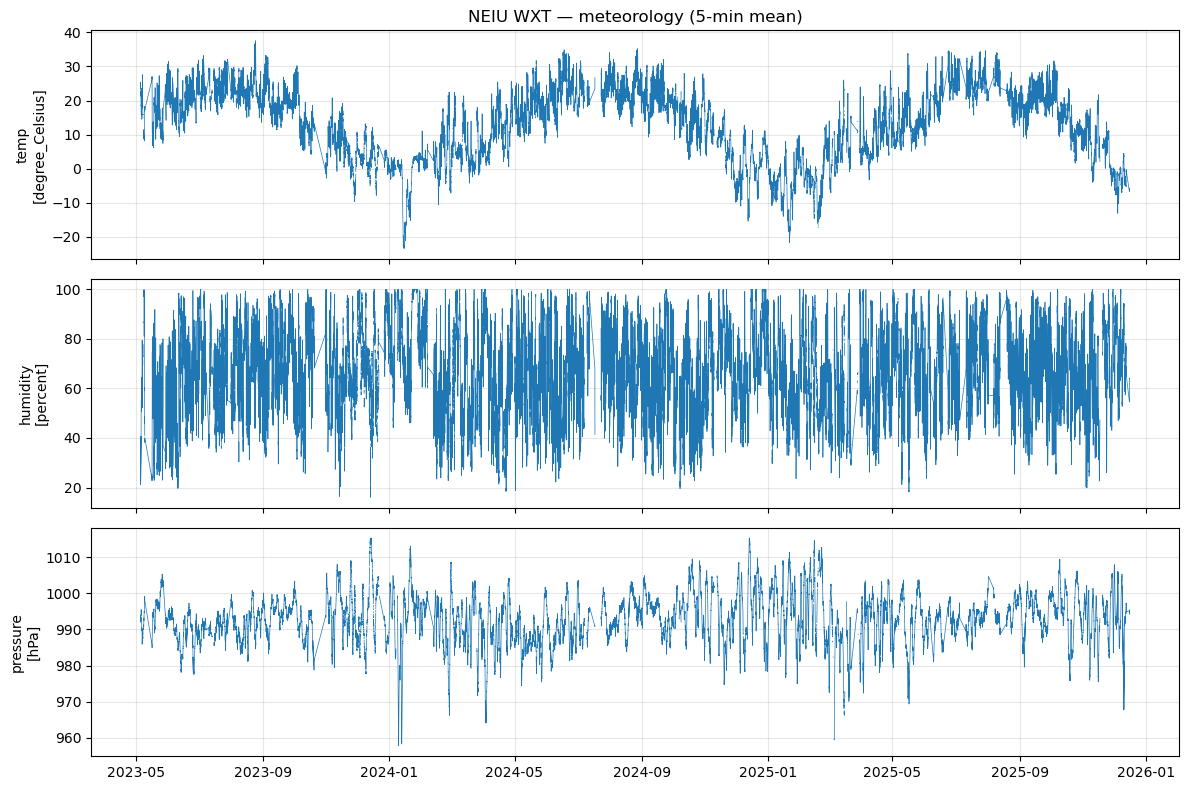

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, var in zip(axes, ['temp', 'humidity', 'pressure']):
    raw, cleaned, u = clean_series(var)
    ax.plot(cleaned.index, cleaned.values, lw=0.5)
    ax.set_ylabel(f'{var}\n[{u}]')
    ax.grid(alpha=0.3)
axes[0].set_title(f'{SITE.abbr} WXT — meteorology (5-min mean)')
fig.tight_layout()
plt.show()

## Wind — vector speed and direction

Recovered from the `wind_u` / `wind_v` component means, *not* the stored scalar
`wind_speed` / `wind_dir`. Components follow the standard meteorological
convention: positive `u` is eastward (a westerly wind), positive `v` is
northward (a southerly). Vector speed is `√(ū² + v̄²)`; the direction the wind
comes *from* is `atan2(-ū, -v̄) % 360`, equivalently `(atan2(ū, v̄) + 180) % 360`.

The scalar `wind_speed` mean is overlaid in grey for contrast — it sits above
the vector speed whenever the wind direction varied within a bin, and the gap
between them is itself a crude gustiness/variability signal.

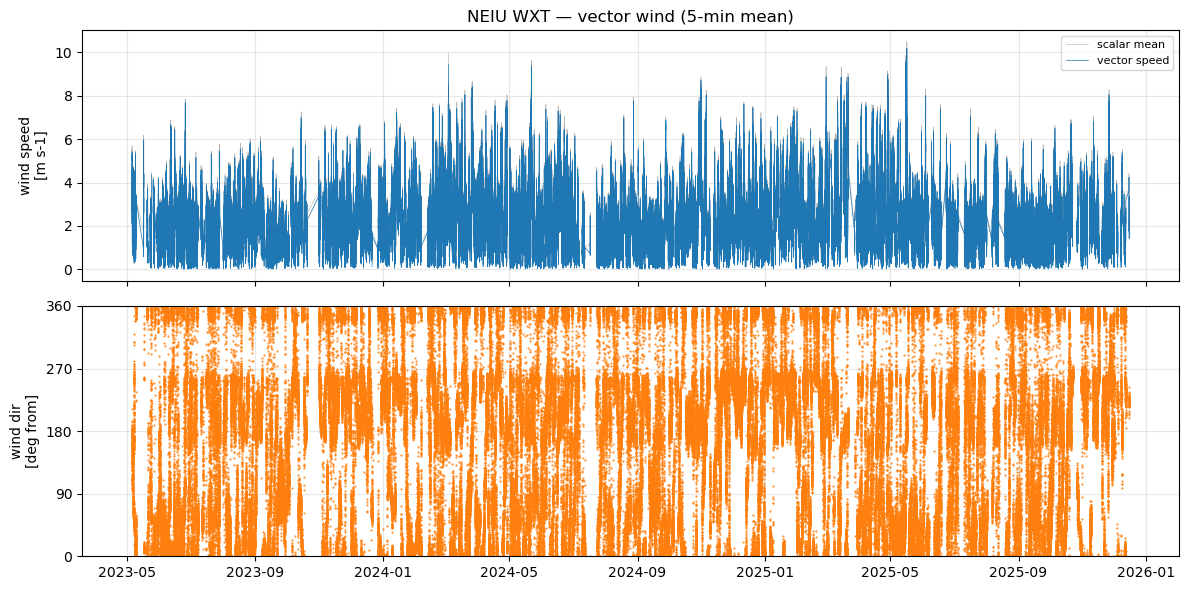

In [ ]:
u = ds['wind_u'].sel(statistic='mean').to_series().where(good.values)
v = ds['wind_v'].sel(statistic='mean').to_series().where(good.values)
scalar_spd = ds['wind_speed'].sel(statistic='mean').to_series().where(good.values)

vec_spd = np.sqrt(u**2 + v**2)
# meteorological 'from' direction: u,v stored as -speed*sin(dir), -speed*cos(dir)
vec_dir = np.degrees(np.arctan2(-u, -v)) % 360

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(scalar_spd.index, scalar_spd.values, lw=0.4,
             color='0.7', label='scalar mean')
axes[0].plot(vec_spd.index, vec_spd.values, lw=0.5,
             color='C0', label='vector speed')
axes[0].set_ylabel('wind speed\n[m s-1]')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(vec_dir.index, vec_dir.values, '.', ms=1, color='C1')
axes[1].set_ylabel('wind dir\n[deg from]')
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].grid(alpha=0.3)

axes[0].set_title(f'{SITE.abbr} WXT — vector wind (5-min mean)')
fig.tight_layout()
plt.show()

## Wind rose

Direction-binned distribution of the vector wind over the whole archive, weighted
by speed. A quick check that the prevailing wind looks physically sane for the
site (e.g. lake-influenced flow at the Chicago lakefront).

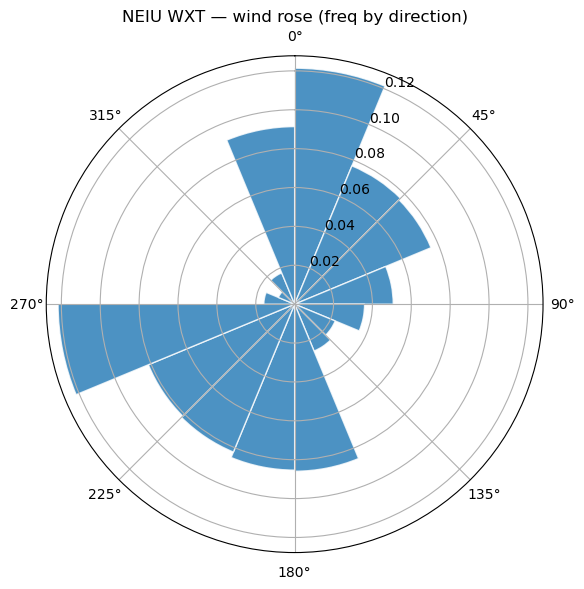

prevailing dir bin (deg from): 248-270


In [7]:
# drop calm/missing bins before binning direction
m = np.isfinite(vec_dir.values) & np.isfinite(vec_spd.values) & (vec_spd.values > 0.3)
d = vec_dir.values[m]
s = vec_spd.values[m]

nbins = 16
edges = np.linspace(0, 360, nbins + 1)
centers = np.deg2rad((edges[:-1] + edges[1:]) / 2)
width = np.deg2rad(360 / nbins)

# mean speed per direction bin, and frequency
idx = np.digitize(d, edges) - 1
idx = np.clip(idx, 0, nbins - 1)
freq = np.array([(idx == i).mean() for i in range(nbins)])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)          # clockwise, compass-style
ax.bar(centers, freq, width=width, color='C0', edgecolor='white', alpha=0.8)
ax.set_title(f'{SITE.abbr} WXT — wind rose (freq by direction)')
fig.tight_layout()
plt.show()

print('prevailing dir bin (deg from):',
      f'{edges[np.argmax(freq)]:.0f}-{edges[np.argmax(freq)+1]:.0f}')

## Rainfall

The `rain` mean slot is already the per-bin accumulation (mm), so a cumulative
sum gives the running rainfall total. Top panel is the 5-min increments (spiky by
nature); bottom is the cumulative total across the archive.

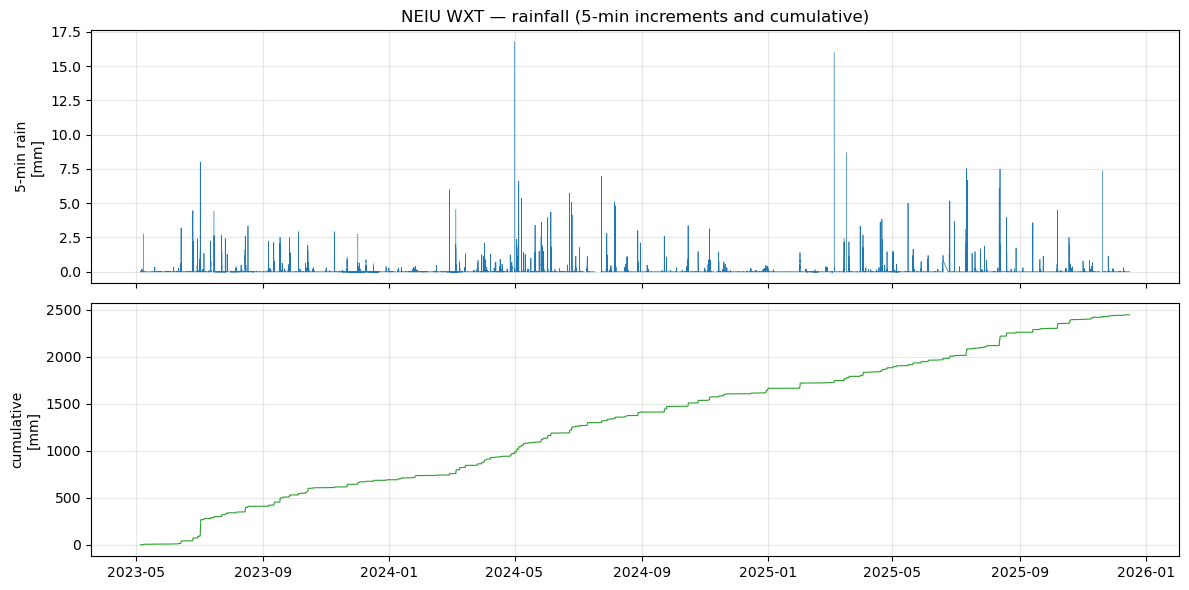

total rainfall over archive : 2457.1 mm
wettest 5-min bin           : 16.77 mm


In [8]:
rain = ds['rain'].sel(statistic='mean').to_series()
# rain doesn't need the count mask the same way — a dry bin is legitimately 0 —
# but mask sparse bins so outage seams don't inject spurious zeros into the sum.
rain_disp = rain.where(good.values)
cum = rain_disp.fillna(0).cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rain_disp.index, rain_disp.values, lw=0.5, color='C0')
axes[0].set_ylabel('5-min rain\n[mm]')
axes[0].grid(alpha=0.3)

axes[1].plot(cum.index, cum.values, lw=0.8, color='C2')
axes[1].set_ylabel('cumulative\n[mm]')
axes[1].grid(alpha=0.3)

axes[0].set_title(f'{SITE.abbr} WXT — rainfall (5-min increments and cumulative)')
fig.tight_layout()
plt.show()

print(f'total rainfall over archive : {np.nansum(rain.values):.1f} mm')
print(f'wettest 5-min bin           : {np.nanmax(rain.values):.2f} mm')

## Data availability and the high-frequency transition

`count` per bin tells two stories at once. Flat high values (~thousands) mean
steady reporting in the historic high-frequency era; a cliff down to ~1 marks the
changeover to native 5-min sampling. Drops to zero are gaps/outages. The log
y-axis makes both the dense era and the single-sample era visible at once.

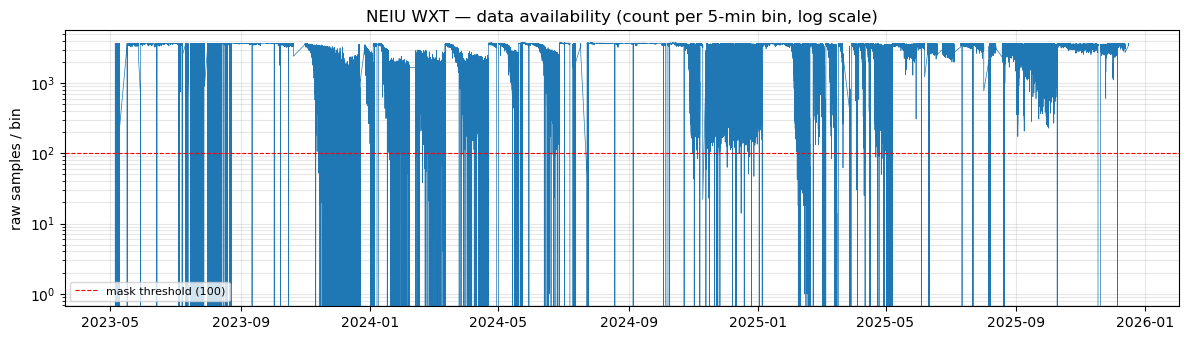

median samples/bin (all)      : 3533
median samples/bin (hi-freq)  : 3545
empty bins (count==0)         : 8074
last high-freq bin            : 2025-12-15 23:55:00


In [9]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(count.index, count.values, lw=0.5)
ax.axhline(MIN_COUNT, color='red', lw=0.8, ls='--',
           label=f'mask threshold ({MIN_COUNT})')
ax.set_yscale('log')
ax.set_ylabel('raw samples / bin')
ax.set_title(f'{SITE.abbr} WXT — data availability (count per 5-min bin, log scale)')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3, which='both')
fig.tight_layout()
plt.show()

hi = count[count > 100]
print('median samples/bin (all)      :', int(count.median()))
print('median samples/bin (hi-freq)  :', int(hi.median()) if len(hi) else 'n/a')
print('empty bins (count==0)         :', int((count == 0).sum()))
if len(hi):
    print('last high-freq bin            :', str(hi.index[-1])[:19])

In [ ]:
ds.close()